# Entrenamiento y Evaluación de TinyML 1D-CNN + TCN (Proto)

Este cuaderno carga el dataset procesado de tensores sEMG ($W=200$) y entrena la red **TinyML SIMD-TCN**.
Provee dos rutas de entrenamiento seleccionables:
- **Opción A:** Entrenamiento Estándar (Sin Poda de Pesos).
- **Opción B:** Entrenamiento con Poda de Pesos (*Weight Pruning* con `tfmot`, del 0% al 70% gradual).

Ambas opciones generan y evalúan el modelo en el conjunto de prueba con y sin **Votación Mayoritaria ($N=5$)**.

In [9]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from pathlib import Path
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from scipy import stats

# 🚀 Detección de GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"🚀 GPU detectada y activada: {gpus[0].name}")
    except Exception as e:
        print(f"ℹ️ Error configurando GPU ({e}), ejecutando en CPU.")
else:
    print("ℹ️ GPU no disponible en esta sesión. Ejecutando en CPU.")

def load_env_variables():
    try:
        start_dir = Path(os.getcwd())
    except:
        start_dir = Path(".")
        
    env_path = None
    for path in [start_dir] + list(start_dir.parents):
        temp_path = path / ".env"
        if temp_path.exists():
            env_path = temp_path
            break
    if env_path is None:
        raise FileNotFoundError("⚠️ No se pudo encontrar el archivo .env en la raíz del proyecto.")
    with open(env_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, val = line.split("=", 1)
            os.environ[key.strip()] = val.strip()
    print(f"✅ Archivo .env cargado con éxito desde: {env_path}")

load_env_variables()
base_path = os.environ["PROCESSED_TENSOR_PROTO"]
models_dir = os.environ["MODELS_DL_PROTO"]

🚀 GPU detectada y activada: /physical_device:GPU:0
✅ Archivo .env cargado con éxito desde: /home/cbe/Proyectos/MyoTensor_Tesis/.env


In [10]:
# 📖 Cargar tensores sEMG procesados
print("📖 Cargando tensores...")
X_train = np.load(os.path.join(base_path, "X_train.npy"))
y_train = np.load(os.path.join(base_path, "y_train.npy"))
X_test  = np.load(os.path.join(base_path, "X_test.npy"))
y_test  = np.load(os.path.join(base_path, "y_test.npy"))

if X_train.ndim == 2:
    X_train = np.expand_dims(X_train, -1)
if X_test.ndim == 2:
    X_test = np.expand_dims(X_test, -1)

print(f"✅ X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"✅ X_test  shape: {X_test.shape}  | y_test  shape: {y_test.shape}")

# Hiperparámetros de entrenamiento
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

📖 Cargando tensores...
✅ X_train shape: (1809, 200, 1) | y_train shape: (1809, 4)
✅ X_test  shape: (470, 200, 1)  | y_test  shape: (470, 4)


## 🟢 Opción A: Entrenamiento Estándar (Sin Poda de Pesos)
*Ejecuta esta celda si deseas entrenar la red sin poda de pesos.*

In [ ]:
# Cargar modelo base TCN
base_model_path = os.path.join(models_dir, "myotensor_proto_net_tcn.keras")
trained_model_path = os.path.join(models_dir, "myotensor_proto_net_tcn_trained.keras")
print(f"📥 Cargando modelo base desde: {base_model_path}")
model_std = tf.keras.models.load_model(base_model_path)

callbacks_std = [
    ModelCheckpoint(filepath=trained_model_path, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
    EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

print("🚀 Iniciando Entrenamiento Estándar TinyML-TCN...")
history_std = model_std.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=callbacks_std,
    verbose=1
)

model_eval = model_std
print(f"✅ Modelo estándar guardado en: {trained_model_path}")

## 🟣 Opción B: Entrenamiento con Poda de Pesos (Weight Pruning Gradual 0% → 70%)
*Ejecuta esta celda si deseas aplicar poda de pesos gradual para optimizar el tamaño en microcontrolador.*

In [11]:
# Cargar modelo base TCN para poda
base_model_path = os.path.join(models_dir, "myotensor_proto_net_tcn.keras")
trained_model_path = os.path.join(models_dir, "myotensor_proto_net_tcn_trained.keras")
print(f"📥 Cargando modelo base para poda desde: {base_model_path}")
base_model = tf.keras.models.load_model(base_model_path)

epochs_pruning = 40
num_samples = X_train.shape[0]
end_step = int(np.ceil(num_samples / batch_size)) * epochs_pruning

pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.70,
        begin_step=0,
        end_step=end_step
    )
}

model_for_pruning = tfmot.sparsity.keras.prune_low_magnitude(base_model, **pruning_params)
model_for_pruning.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_pruning = [
    ModelCheckpoint(filepath=trained_model_path, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
    EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1),
    tfmot.sparsity.keras.UpdatePruningStep()
]

print("🚀 Iniciando Entrenamiento TCN con Weight Pruning...")
history_pruning = model_for_pruning.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs_pruning,
    callbacks=callbacks_pruning,
    verbose=1
)

# Stripping: Eliminar la sobrecarga de poda para exportar pesos planos
model_stripped = tfmot.sparsity.keras.strip_pruning(model_for_pruning)
model_stripped.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_stripped.save(trained_model_path)
model_eval = model_stripped
print(f"✅ Modelo TCN podado guardado y exportado en: {trained_model_path}")

📥 Cargando modelo base para poda desde: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_tcn.keras
🚀 Iniciando Entrenamiento TCN con Weight Pruning...
Epoch 1/40
55/57 [===========================>..] - ETA: 0s - loss: 1.3685 - accuracy: 0.2313
Epoch 1: val_accuracy improved from -inf to 0.55106, saving model to /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_tcn_trained.keras
57/57 [==============================] - 7s 25ms/step - loss: 1.3658 - accuracy: 0.2394 - val_loss: 1.2905 - val_accuracy: 0.5511 - lr: 0.0010
Epoch 2/40
54/57 [===========================>..] - ETA: 0s - loss: 1.2182 - accuracy: 0.5428
Epoch 2: val_accuracy improved from 0.55106 to 0.61915, saving model to /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_tcn_trained.keras
57/57 [==============================] - 5s 87ms/step - loss: 1.2121 - accuracy: 0.5495 - val_loss: 1.113

## 📊 Evaluación del Modelo Entrenado

📥 Cargando modelo entrenado desde: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/dl/myotensor_proto_net_tcn_trained.keras
15/15 [==============================] - 0s 5ms/step
🎯 Test Accuracy (Cruda por ventana): 81.28%
🚀 Test Accuracy (Con Votación Mayoritaria N=5): 83.83%

📋 Reporte de Clasificación TinyML-TCN (Votación Mayoritaria):
              precision    recall  f1-score   support

      Reposo       0.94      0.99      0.97       155
       Palma       0.70      0.73      0.71       104
        Puño       0.94      0.93      0.93       109
         Paz       0.70      0.63      0.66       102

    accuracy                           0.84       470
   macro avg       0.82      0.82      0.82       470
weighted avg       0.84      0.84      0.84       470



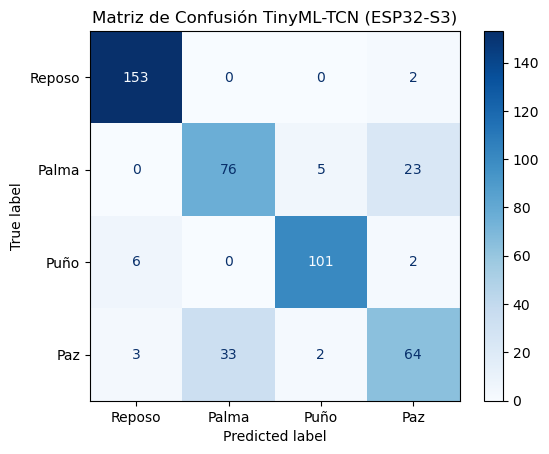

In [12]:
# Cargar el mejor modelo guardado para evaluación
print(f"📥 Cargando modelo entrenado desde: {trained_model_path}")
final_model = tf.keras.models.load_model(trained_model_path)

y_pred_prob = final_model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

acc_raw = accuracy_score(y_true_classes, y_pred_classes)
print(f"🎯 Test Accuracy (Cruda por ventana): {acc_raw * 100:.2f}%")

# Aplicar Votación Mayoritaria (Majority Voting N=5, simula firmware)
def apply_majority_voting(predictions, window_size=5):
    smoothed = []
    for i in range(len(predictions)):
        start_idx = max(0, i - window_size + 1)
        w = predictions[start_idx : i + 1]
        mode_val = stats.mode(w, keepdims=False)[0]
        smoothed.append(mode_val)
    return np.array(smoothed)

y_pred_smooth = apply_majority_voting(y_pred_classes, window_size=5)
acc_smooth = accuracy_score(y_true_classes, y_pred_smooth)
print(f"🚀 Test Accuracy (Con Votación Mayoritaria N=5): {acc_smooth * 100:.2f}%")

gesture_names = ["Reposo", "Palma", "Puño", "Paz"]
print("\n📋 Reporte de Clasificación TinyML-TCN (Votación Mayoritaria):")
print(classification_report(y_true_classes, y_pred_smooth, target_names=gesture_names))

# Matriz de Confusión
cm = confusion_matrix(y_true_classes, y_pred_smooth)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gesture_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión TinyML-TCN (ESP32-S3)")
plt.show()